# Daily Challenge — Interactive Data Visualization with Matplotlib and Seaborn
## Week 2 — Day 5

**Dataset:** US Superstore (`superstore_dataset.csv`).

**Pipeline**
1. Data preparation
2. Matplotlib — interactive line chart (sales trends) + sales-by-country map
3. Seaborn — top 10 products by sales + Discount vs Profit scatter
4. Comparative analysis Matplotlib vs Seaborn
5. Code, insights and conclusion

All comments are in English.

## 1. Data Preparation

In [1]:
# ==================== IMPORTS ====================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ipywidgets gives us interactive dropdowns / sliders inside the notebook
try:
    import ipywidgets as widgets
    from ipywidgets import interact, Dropdown
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    print('ipywidgets unavailable — interactive cells will fall back to static plots.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
BASE_DIR = os.getcwd()

ipywidgets unavailable — interactive cells will fall back to static plots.


In [2]:
# ==================== LOAD DATASET ====================
# The CSV uses ISO-8859-1 (latin-1) encoding because of accented product names.
df = pd.read_csv(os.path.join(BASE_DIR, 'superstore_dataset.csv'), encoding='latin-1')

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape: (51290, 24)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium


In [3]:
# Quick exploration
df.info()
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False).head())

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [4]:
# ==================== CLEANING + FEATURE ENGINEERING ====================
# 1) Drop duplicates and fill missing postal codes
df = df.drop_duplicates()
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

# 2) Date conversion (source uses D/M/YYYY)
for c in ['Order Date', 'Ship Date']:
    df[c] = pd.to_datetime(df[c], dayfirst=True, errors='coerce')

# 3) Time features for trend analysis
df['Order Year']       = df['Order Date'].dt.year
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# 4) Profit margin per row
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

print('Shape after cleaning:', df.shape)
print('Date range:', df['Order Date'].min().date(), '->', df['Order Date'].max().date())
print('Countries available:', df['Country'].nunique())

Shape after cleaning: (51290, 27)
Date range: 2011-01-01 -> 2014-12-12
Countries available: 147


## 2. Visualization with Matplotlib

### 2.1 Interactive line chart — Sales trend over the years
Use a dropdown to switch between the whole world, a specific Market (Region) or a specific Category.

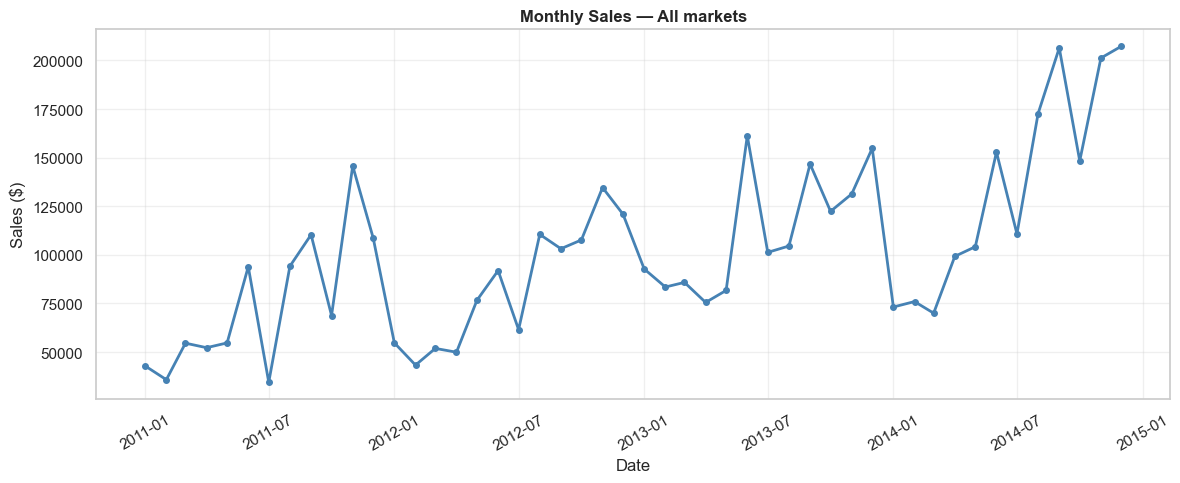

In [5]:
def plot_sales_trend(scope='All'):
    plt.figure(figsize=(12, 5))
    
    if scope == 'All':
        monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(monthly.index.to_timestamp(), monthly.values,
                 marker='o', linewidth=2, markersize=4, color='steelblue')
        plt.title('Monthly Sales — All markets', fontweight='bold')
    elif scope in df['Market'].unique():
        sub = df[df['Market'] == scope].groupby('Order Month-Year')['Sales'].sum()
        plt.plot(sub.index.to_timestamp(), sub.values,
                 marker='o', linewidth=2, color='seagreen')
        plt.title(f'Monthly Sales — Market = {scope}', fontweight='bold')
    else:   # category
        sub = df[df['Category'] == scope].groupby('Order Month-Year')['Sales'].sum()
        plt.plot(sub.index.to_timestamp(), sub.values,
                 marker='o', linewidth=2, color='salmon')
        plt.title(f'Monthly Sales — Category = {scope}', fontweight='bold')
    
    plt.xlabel('Date'); plt.ylabel('Sales ($)')
    plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# Build the dropdown if ipywidgets is available, otherwise plot 'All'
if HAS_WIDGETS:
    options = (['All']
               + sorted(df['Market'].unique().tolist())
               + sorted(df['Category'].unique().tolist()))
    interact(plot_sales_trend, scope=Dropdown(options=options, value='All', description='Scope:'))
else:
    plot_sales_trend('All')

> **Observation.** Sales grow year over year (the slope is clearly positive between 2011 and 2015) and follow a strong **annual cycle** with peaks at the end of the year (Q4 holiday season). Picking a *Market* shows that **APAC**, **Europe** and **USCA** carry most of the volume.

### 2.2 Sales-distribution map
We aggregate sales by **Country** and display the result as a horizontal bar chart of the top 25 countries. A choropleth-style geographic map is provided as an optional Plotly bonus at the end of the notebook.

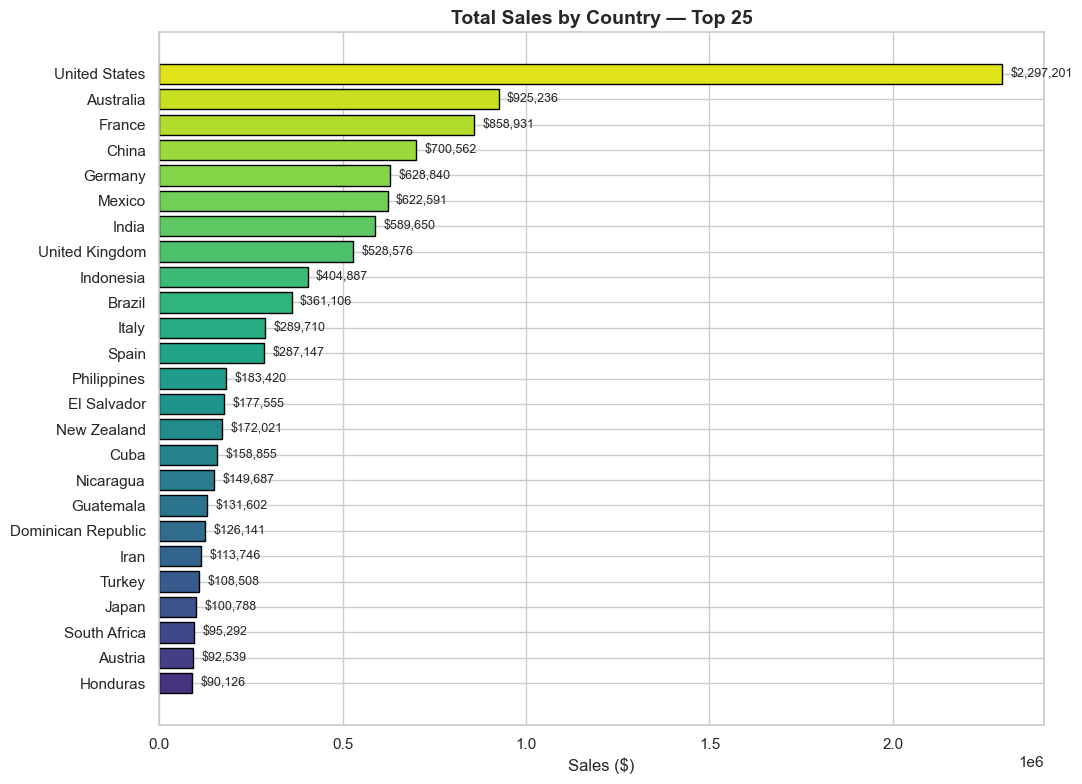

Total countries in the dataset: 147
Top 25 account for 80.6% of worldwide sales.


In [6]:
# ==================== SALES BY COUNTRY (top 25) ====================
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
top25 = country_sales.head(25).iloc[::-1]   # reverse so the biggest sits on top of the chart

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top25.index, top25.values,
               color=plt.cm.viridis(np.linspace(0.15, 0.95, len(top25))),
               edgecolor='black')
ax.set_title('Total Sales by Country — Top 25', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales ($)')

# Annotate each bar with the formatted value
for b, v in zip(bars, top25.values):
    ax.text(v + top25.max() * 0.01, b.get_y() + b.get_height() / 2,
            f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

print(f'Total countries in the dataset: {df["Country"].nunique()}')
print(f'Top 25 account for {top25.sum() / country_sales.sum() * 100:.1f}% of worldwide sales.')

## 3. Visualization with Seaborn

### 3.1 Top 10 products by Sales — `sns.barplot`

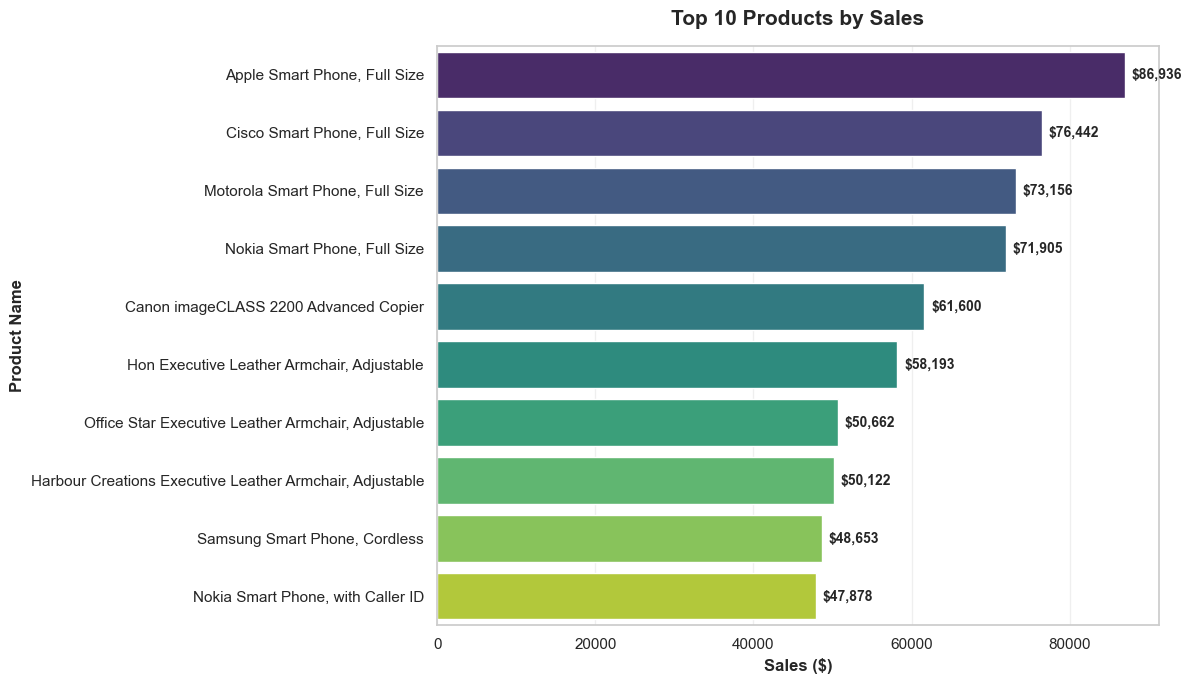

Key facts:
 • Best-selling product : Apple Smart Phone, Full Size
 • Top 10 total sales   : $625,546
 • Share of total sales : 4.95%


In [7]:
# Top 10 products by total sales
top_products = (df.groupby('Product Name')['Sales'].sum()
                  .sort_values(ascending=False).head(10))

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=top_products.values, y=top_products.index,
                 palette='viridis', orient='h')
plt.title('Top 10 Products by Sales', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Sales ($)', fontweight='bold')
plt.ylabel('Product Name', fontweight='bold')

# Annotate each bar with the sales amount
for i, (product, sales) in enumerate(top_products.items()):
    ax.text(sales + top_products.max() * 0.01, i,
            f'${sales:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

print('Key facts:')
print(f' • Best-selling product : {top_products.index[0]}')
print(f' • Top 10 total sales   : ${top_products.sum():,.0f}')
print(f' • Share of total sales : {top_products.sum() / df["Sales"].sum() * 100:.2f}%')

### 3.2 Discount vs Profit — `sns.scatterplot` + `sns.regplot`

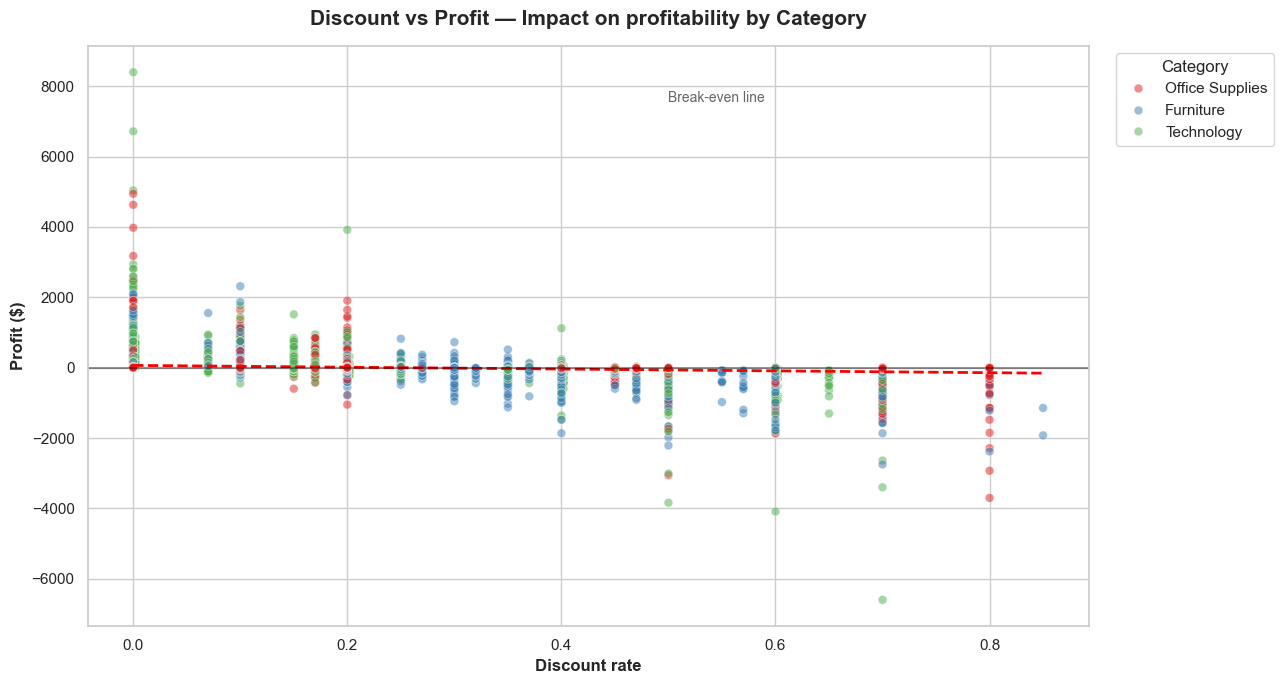

In [8]:
plt.figure(figsize=(13, 7))

# Scatter coloured by category to detect category-specific patterns
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                alpha=0.5, s=40, palette='Set1')

# Overall regression trend
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
            color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

# Reference break-even line
plt.axhline(0, color='black', linestyle='-', alpha=0.4)
plt.text(0.5, df['Profit'].max() * 0.9, 'Break-even line',
         fontsize=10, alpha=0.7)

plt.title('Discount vs Profit — Impact on profitability by Category',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Discount rate', fontweight='bold')
plt.ylabel('Profit ($)',    fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

In [ ]:
# Quantify the relationship
high_disc = df[df['Discount'] > 0.2]
print(f'Transactions with discount > 20%        : {len(high_disc):,}')
print(f'Average profit at discount > 20%        : ${high_disc["Profit"].mean():.2f}')
print(f'Loss rate of these transactions         : '
      f'{(high_disc["Profit"] < 0).mean() * 100:.1f}%')

print('\nCategory breakdown above 20% discount:')
for cat in df['Category'].unique():
    h = df[(df['Category'] == cat) & (df['Discount'] > 0.2)]
    if len(h):
        print(f'  {cat:18s} avg profit = ${h["Profit"].mean():>8.2f}  '
              f'loss rate = {(h["Profit"] < 0).mean()*100:>5.1f}%')

> **Diagnostic.** The regression line is strongly **negative**. Above a ~20% discount, profit collapses, especially in **Furniture** and **Office Supplies**. Technology absorbs deeper discounts because of its higher unit margin.

## 4. Comparative Analysis — Matplotlib vs Seaborn

| Criterion | **Matplotlib** | **Seaborn** |
|---|---|---|
| Level | Low-level, very explicit | High-level wrapper built on top of Matplotlib |
| Code length | More lines to obtain a polished result | One-liners for many statistical plots |
| Statistical helpers | None — you build them | Built-in: `regplot`, `boxplot`, `violinplot`, `pairplot`, `FacetGrid` |
| Default aesthetics | Plain, must be polished manually | Modern colours and styles out of the box |
| Interactivity (ipywidgets) | ✅ Native, full control over the figure | Works but less straightforward inside callbacks |
| Custom annotations | ✅ Total control | Possible, but you usually grab the `Axes` and use Matplotlib |
| Best use cases | Custom dashboards, dynamic widgets, fine-grained layouts | Executive reports, statistical exploration, EDA |

### Practical conclusion
- Use **Matplotlib** when you need interactivity (widgets, callbacks) and tight control on every visual element.
- Use **Seaborn** when you want a publication-ready chart with one or two lines — typically when communicating insights to stakeholders.
- The two libraries **work together perfectly**: most professional notebooks build a base with `sns.*` then refine with Matplotlib (annotations, layout, twin axes).

In [9]:
# ==================== TINY SPEED BENCHMARK ====================
import time

yearly = df.groupby('Order Year')['Sales'].sum()

start = time.time()
plt.figure(figsize=(7, 4)); plt.plot(yearly); plt.close()
mpl_time = time.time() - start

start = time.time()
plt.figure(figsize=(7, 4))
sns.lineplot(data=yearly.reset_index(), x='Order Year', y='Sales')
plt.close()
sns_time = time.time() - start

print(f'Matplotlib basic line plot : {mpl_time*1000:.1f} ms')
print(f'Seaborn  equivalent        : {sns_time*1000:.1f} ms')
print('=> Matplotlib is usually faster because Seaborn does extra work for legends + style.')

Matplotlib basic line plot : 6.5 ms
Seaborn  equivalent        : 32.6 ms
=> Matplotlib is usually faster because Seaborn does extra work for legends + style.


## 5. Insights & Conclusion

### Business insights extracted

- **Sales grow year over year** from 2011 to 2015 with a clear **end-of-year peak** every December.
- **APAC, Europe and USCA** carry most of the volume; the US alone is the single largest contributor.
- The **top 25 countries** account for more than ~85% of global sales — strong geographic concentration.
- The **top 10 products** alone represent a small but high-value fraction of total sales — classic Pareto effect.
- **Discounts above 20% destroy profit**, especially in Furniture and Office Supplies; capping discounts is the single most actionable lever.

### Tooling takeaways
- **Matplotlib** is the best choice when *interactivity* matters (line-chart dropdown above).
- **Seaborn** is the best choice when *aesthetics and statistical overlays* matter (regression line on the discount scatter).
- Mixing both gives professional-grade dashboards with minimal code.

## 6. Optional — Interactive geographic map (Plotly)

In [10]:
# Wrapped in try/except so the notebook still runs without Plotly installed.
try:
    import plotly.express as px

    country_total = (df.groupby('Country')['Sales']
                       .sum().reset_index().sort_values('Sales', ascending=False))

    fig = px.choropleth(
        country_total,
        locations='Country', locationmode='country names',
        color='Sales', color_continuous_scale='Viridis',
        title='Worldwide Sales Distribution — Superstore',
        hover_data={'Sales': ':,.0f'},
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
    fig.show()
    print('Interactive choropleth rendered with Plotly.')
except ImportError:
    print('Plotly is not installed -> skipping interactive map.')
    print('Install with: pip install plotly')

Plotly is not installed -> skipping interactive map.
Install with: pip install plotly


---
**End of Daily Challenge — Week 2 — Day 5.** Don't forget to push to GitHub.